In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjuntejaswi/plant-village")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/arjuntejaswi/plant-village/versions/1


In [7]:
image_size=256
batch_size=8
channels=3

In [8]:
import os
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
# List all class names in the dataset directory
all_classes = os.listdir(os.path.join(path, "PlantVillage"))
potato_classes = [c for c in all_classes if "potato" in c.lower()]

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(path, "PlantVillage"),
    batch_size=batch_size,
    image_size=(image_size, image_size),
    shuffle=True,
    class_names=potato_classes
)

Found 2152 files belonging to 3 classes.


2025-08-04 16:52:28.139317: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
class_names=dataset.class_names
class_names

['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']

In [10]:
len(dataset)

269

2025-08-04 16:52:40.264385: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


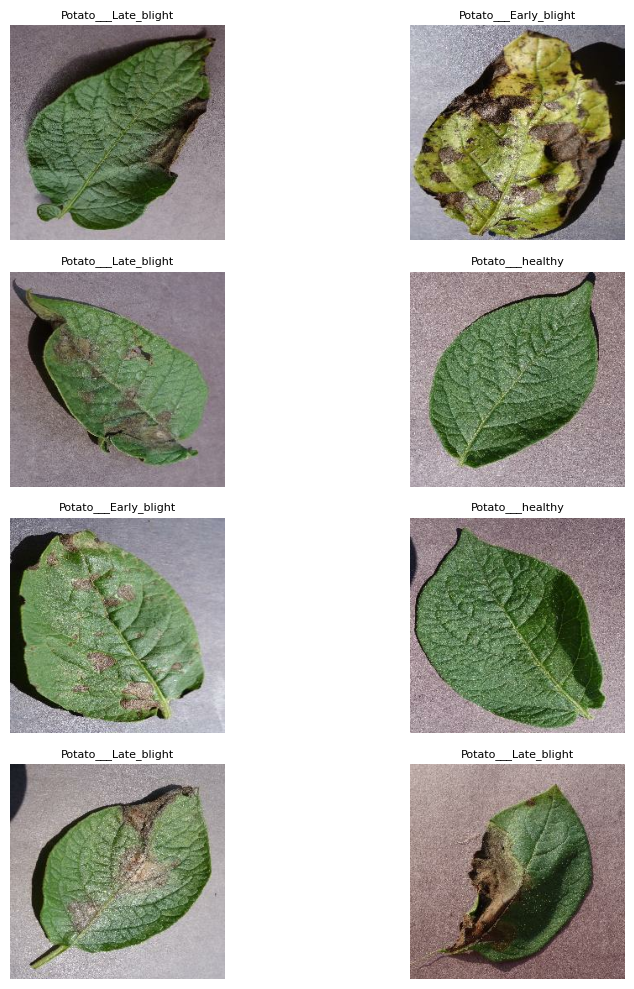

In [11]:
plt.figure(figsize=(10,10))
for image_batch , label_batch in dataset.take(1):
  # Loop through the elements in the batch
  for i in range(batch_size): # Changed range to batch_size
    ax=plt.subplot(4,int(batch_size/4),i+1) # Adjusted subplot columns based on batch size for better layout
    plt.imshow(image_batch[i].numpy().astype('uint8'))
    plt.title(class_names[label_batch[i]], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
def get_dataset_partitions_tf(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):
  ds_size=len(ds)
  train_size=int(ds_size*train_split)
  val_size=int(ds_size*val_split)
  
  if shuffle:
    ds=ds.shuffle(shuffle_size,seed=12)
  train_ds=ds.take(train_size)
  val_ds=ds.skip(train_size).take(val_size)
  test_ds=ds.skip(train_size).skip(val_size)

  
  return train_ds,val_ds,test_ds

In [13]:
train_ds,val_ds,test_ds=get_dataset_partitions_tf(dataset)

In [14]:
len(train_ds),len(val_ds),len(test_ds)

(215, 26, 28)

In [15]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [16]:
resize_and_rescale=tf.keras.Sequential([
    tf.keras.layers.Resizing(image_size,image_size),
    tf.keras.layers.Rescaling(1.0/255,input_shape=(image_size,image_size,channels))
])

/root/anaconda3/lib/python3.12/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
])

In [19]:
from tensorflow.keras import layers, models

input_shape = (image_size, image_size, channels)
n_classes = len(class_names)

model = models.Sequential([
    tf.keras.Input(shape=input_shape),
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 868,643 (3.31 MB)

 Trainable params: 868,643 (3.31 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.build(input_shape=(None, image_size, image_size, channels))

In [21]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    train_ds,
    batch_size=batch_size,
    validation_data=val_ds,
    verbose=2,  # Set to 2 for detailed output per epoch
    epochs=50
)

Epoch 1/50
215/215 - 66s - 307ms/step - accuracy: 0.7203 - loss: 0.6531 - val_accuracy: 0.8221 - val_loss: 0.4162
Epoch 2/50
215/215 - 48s - 225ms/step - accuracy: 0.8465 - loss: 0.3669 - val_accuracy: 0.8846 - val_loss: 0.3705
Epoch 3/50
215/215 - 48s - 223ms/step - accuracy: 0.8860 - loss: 0.2795 - val_accuracy: 0.8173 - val_loss: 0.4244
Epoch 4/50
215/215 - 46s - 215ms/step - accuracy: 0.8779 - loss: 0.3182 - val_accuracy: 0.9183 - val_loss: 0.2381
Epoch 5/50
215/215 - 46s - 213ms/step - accuracy: 0.9407 - loss: 0.1762 - val_accuracy: 0.9183 - val_loss: 0.1958
Epoch 6/50
215/215 - 94s - 438ms/step - accuracy: 0.9262 - loss: 0.1841 - val_accuracy: 0.9279 - val_loss: 0.1638
Epoch 7/50
215/215 - 46s - 214ms/step - accuracy: 0.9424 - loss: 0.1539 - val_accuracy: 0.8990 - val_loss: 0.2466
Epoch 8/50
215/215 - 53s - 247ms/step - accuracy: 0.9238 - loss: 0.2067 - val_accuracy: 0.8702 - val_loss: 0.2937
Epoch 9/50
215/215 - 63s - 294ms/step - accuracy: 0.9384 - loss: 0.1663 - val_accuracy: 

In [23]:
scores=model.evaluate(test_ds, verbose=2)

28/28 - 4s - 130ms/step - accuracy: 0.9241 - loss: 0.1779


In [24]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']


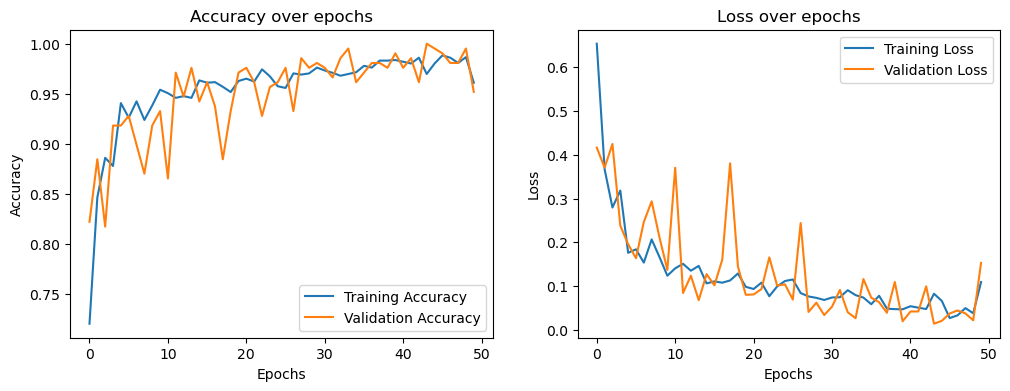

In [26]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

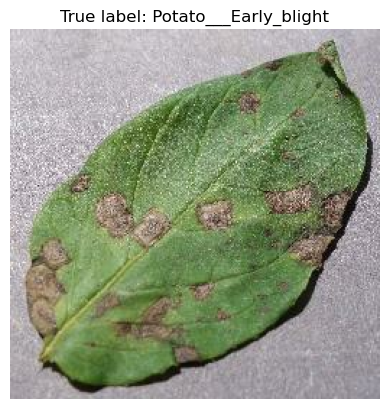

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step
Predicted label: Potato___Early_blight


In [28]:
for images_batch,labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    plt.imshow(first_image)
    plt.title(f"True label: {class_names[first_label]}")
    plt.axis("off")
    plt.show()
    
    print(f"Predicted label: {class_names[model.predict(images_batch)[0].argmax()]}")

In [29]:
def predict_batch(model, images):
    preds = model.predict(images)
    for idx, pred in enumerate(preds):
        confidence = tf.reduce_max(pred).numpy()
        predicted_class = class_names[tf.argmax(pred).numpy()]
        print(f"Image {idx}: Predicted - {predicted_class} (Confidence: {confidence:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


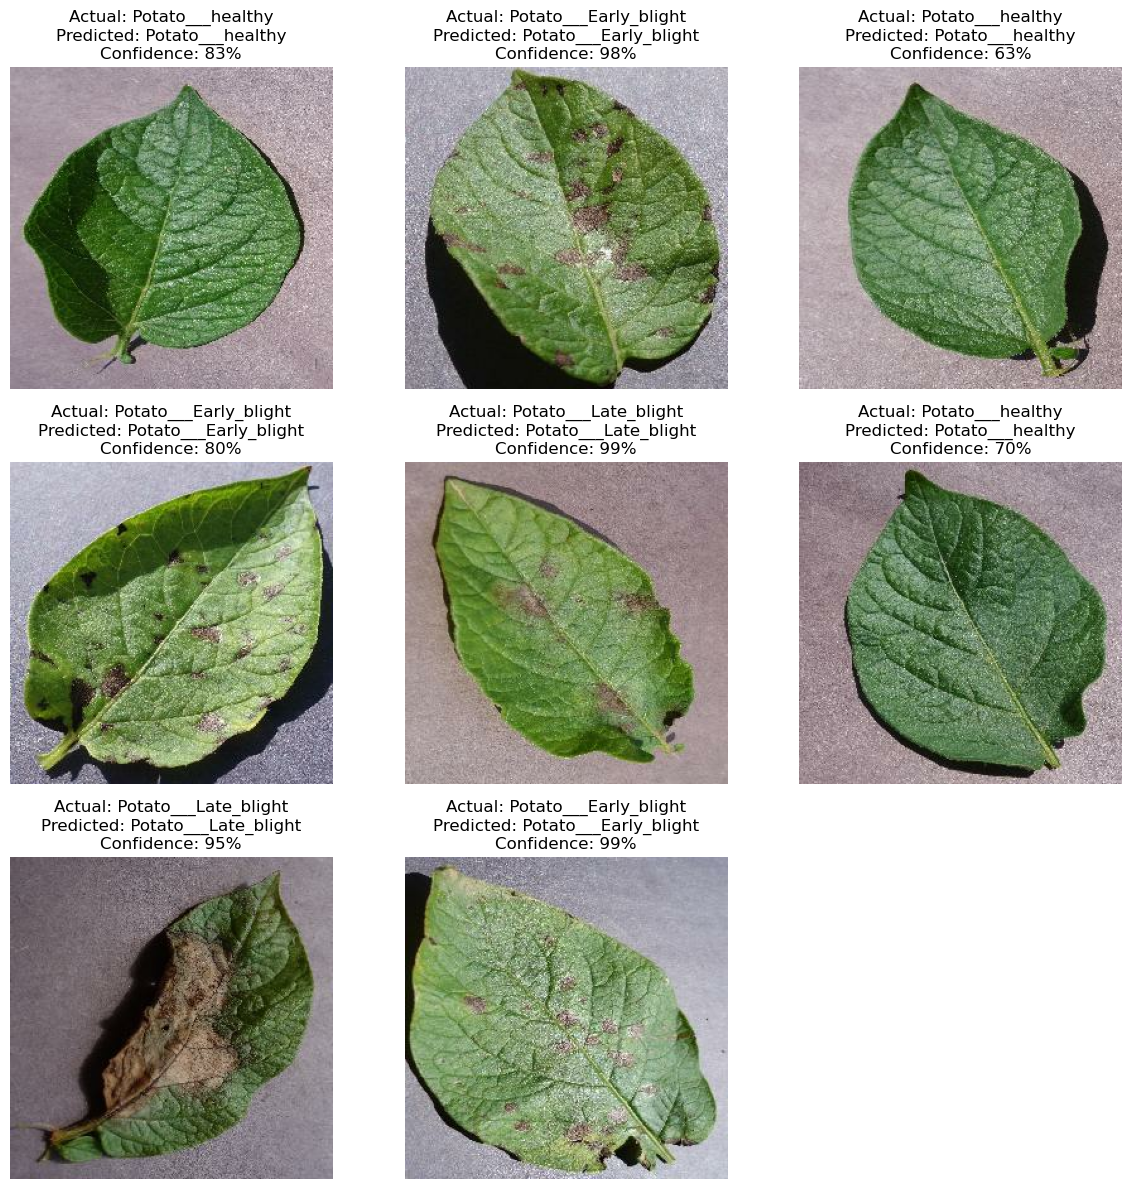

In [35]:
import numpy as np


for images, labels in test_ds.take(1):
    plt.figure(figsize=(12, 12))
    for i in range(8):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        actual_label = class_names[labels[i].numpy()]
        predicted_label = class_names[model.predict(images[i:i+1])[0].argmax()]
        confidence = round(100 * (np.max(model.predict(images[i:i+1]))))
        plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}\nConfidence: {confidence}%")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [42]:
model.save("models/1.keras")
